# Project Output - Investigation into the Collatz Sequence

## Important Note

This document is a PDF export of the main Jupyter notebook used for the investigation.

For full access to the project, including all Python files, code structure, and generated outputs, please refer to the GitHub repository: https://github.com/georgeramble/MATH2002-Collatz-Investigation

The repository contains the complete work for each section, allowing you to review and run the whole code.  


## Overview

This notebook summarises the python code used in our investigation of the Collatz Sequence and focuses on explaining our work. It will guide through the main functions we created, how we generated data and what mathematical conclusions we can take from these outputs.

The main sections to this investigation are:
- Standard behaviour of the Collatz sequence
- S2
- Variants of the Collatz Sequence
- The Collatz Tree

In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt

These are the key python libraries we used in the project, to output data so that we can effectively visualise sequence behaviour.

## Prologue: The Collatz Function

The Collatz sequence is defined below:

$$
f(n) =
\begin{cases}
\frac{n}{2}, & \text{if } n \text{ is even} \\
3n + 1, & \text{if } n \text{ is odd}
\end{cases}
$$

The Collatz conjecture is a famous and unproven conjecture that states that when we repeatedly iterate this function it will eventually reach zero for every positive integer.

This indicates the starting point of our project, with our first tasks being to produce core functions that will define the Collatz sequence in python.

### Function: one Collatz step

```one_step()``` is the first simple function performs one iteration of the Collatz sequence.

This is the fundamental idea that later core functions build upon.

It was later paired with the helper function: ```validate_input()``` as an extra, which rejects invalid inputs.

In [ ]:
def validate_input(n):
    '''
    Checks if input is valid (researched how to raise TypeError)
    '''
    
    if type(n) != int:
        raise TypeError("n must be an integer")
    if n <= 0:
        raise ValueError("n must be positive")

In [17]:
def one_step(n):
    '''
    Does one step of the Collatz seq
    '''
    validate_input(n)

    if n%2==0:
        return n//2
    else:
        return 3*n+1

In [18]:
print(one_step(6))
print(one_step(11))

3
34


### Function: The Collatz sequence

The function: ```collatz_sequence()``` repeatdely applies the Collatz rule until we reach 1. Now that we have coded the Collatz sequence we can use this to study it further.

In [19]:
def collatz_sequence(n):
    '''
    Start a Collatz sequence from n
    '''
    validate_input(n)

    seq = [n]

    while seq[-1]!=1:
        seq.append(one_step(seq[-1]))
    return seq

In [20]:
collatz_sequence(21)

[21, 64, 32, 16, 8, 4, 2, 1]

These functions can all be found in the file: ```collatz_functions.py``` along with some of the other core functions from section 1.

## Section 1: Standard behaviour

This section explores coding key properties of an ordinary Collatz sequence and judging its behaviour for different simulations sizes for the first 'N' values of the sequence.

### Properties of the Collatz rule

There are two main properties we wanted to explore for values of the Collatz sequence. These are:

- Stopping time: The number of steps it takes to reach 1.
- Maximum excursion: The highest number the sequence reaches.

Below are the functions ```stopping_time()``` and ```max_excursion()``` respectively.

In [21]:
def stopping_time(n):
    '''
    Number of steps needed to reach 1
    '''

    return len(collatz_sequence(n))-1

In [22]:
def max_excursion(n):
    '''
    Maximum value reached in the sequence
    '''

    return max(collatz_sequence(n))

In [23]:
collatz_sequence(7)

[7, 22, 11, 34, 17, 52, 26, 13, 40, 20, 10, 5, 16, 8, 4, 2, 1]

In [24]:
stopping_time(7)

16

In [25]:
max_excursion(7)

52

### Running simulations of the Collatz sequence

What was next, was to create a function that ran multiple Collatz sequence from 1 to a give value N and store each seperate property in a list.

This involved basic iteration defined in the function ```collatz_simmulations()``` below.

In [26]:
def collatz_simulations(N):
    '''
    Run Collatz simulations for 1<=n<=N.

    Returns three lists:
    - starting values
    - stopping times
    - maximum excursions
    '''

    validate_input(N)

    starting_values = []
    stopping_times = []
    max_values = []

    for n in range(1,N+1):

        starting_values.append(n)
        stopping_times.append(stopping_time(n))
        max_values.append(max_excursion(n))

    return starting_values, stopping_times, max_values

In [27]:
collatz_simulations(10)

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [0, 1, 7, 2, 5, 8, 16, 3, 19, 6],
 [1, 2, 16, 4, 16, 16, 52, 8, 52, 16])

### Plotting results for stopping time and maximum excursion

This finally left us to output different results in order to visualise stopping times and maximum excursion as the value of N increased.

This involved defining three functions:
- plot of stopping times
- plot of maximum excursion
- plot of stopping times vs. maximum excursion

You can see the code for this in ```section1_standard_behaviour.py```.

Below allows us to output a summary and the three plots for selected values of N.


-----------------------------
Running for N = 50
Largest stopping time: 111 at n = 27
Largest maximum excursion: 9232 at n = 27
Average stopping time: 21.32
Range of stopping times: 0 to 111
Range of maximum excursions: 1 to 9232


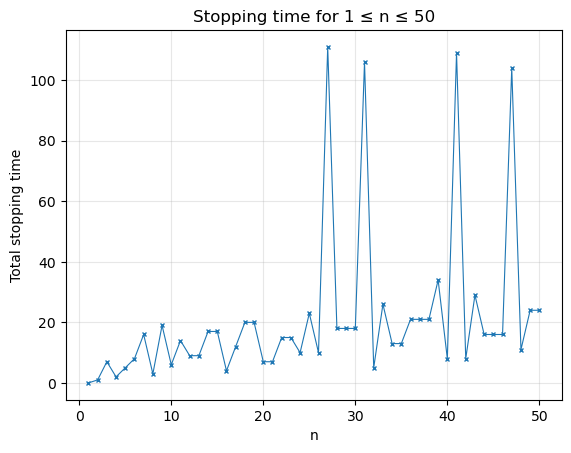

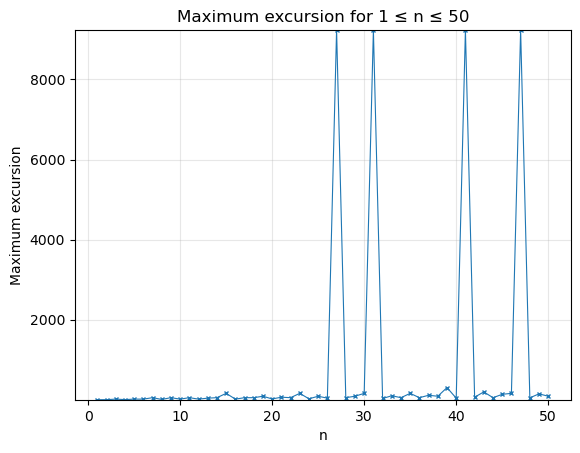

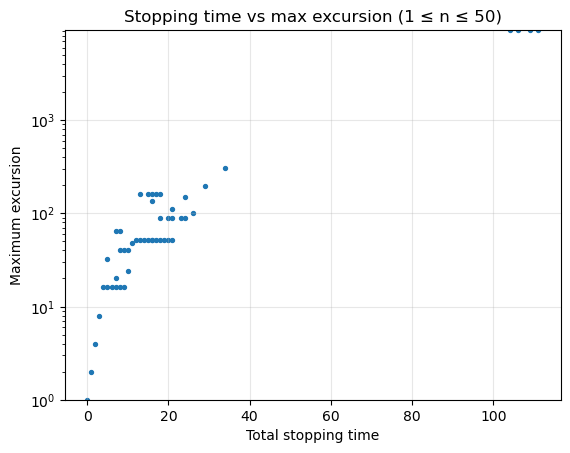


-----------------------------
Running for N = 200
Largest stopping time: 124 at n = 171
Largest maximum excursion: 9232 at n = 27
Average stopping time: 42.09
Range of stopping times: 0 to 124
Range of maximum excursions: 1 to 9232


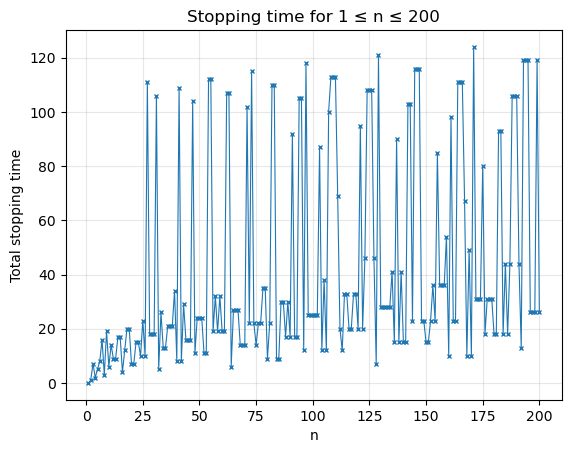

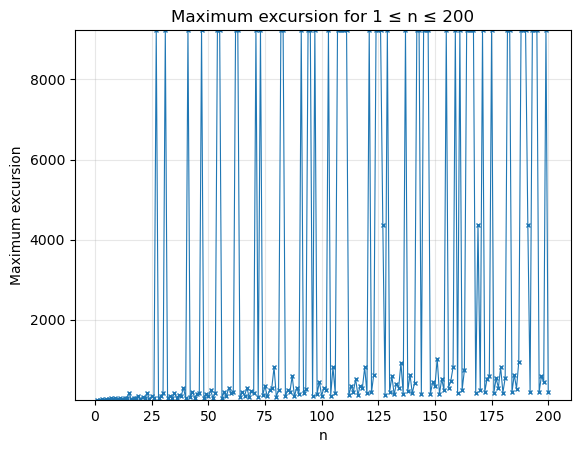

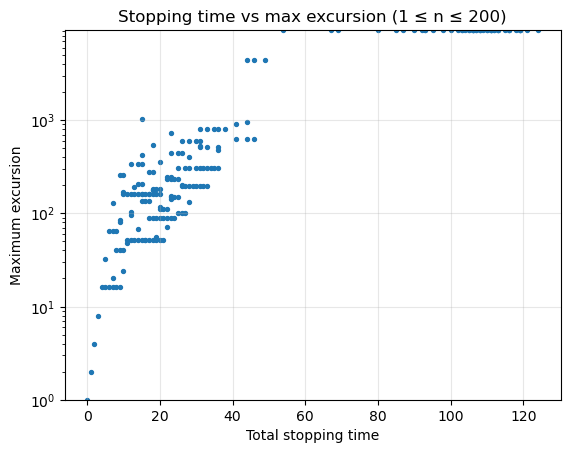


-----------------------------
Running for N = 500
Largest stopping time: 143 at n = 327
Largest maximum excursion: 39364 at n = 447
Average stopping time: 52.286
Range of stopping times: 0 to 143
Range of maximum excursions: 1 to 39364


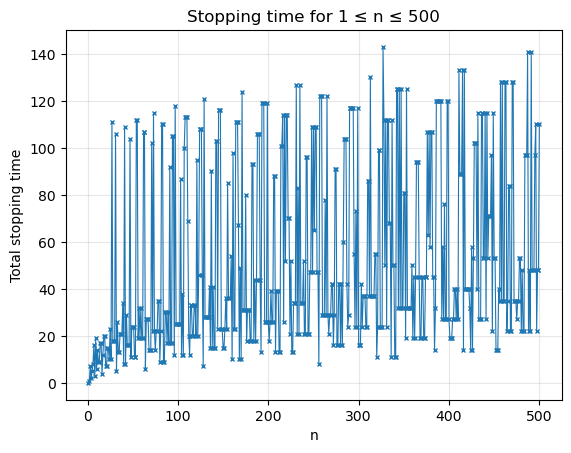

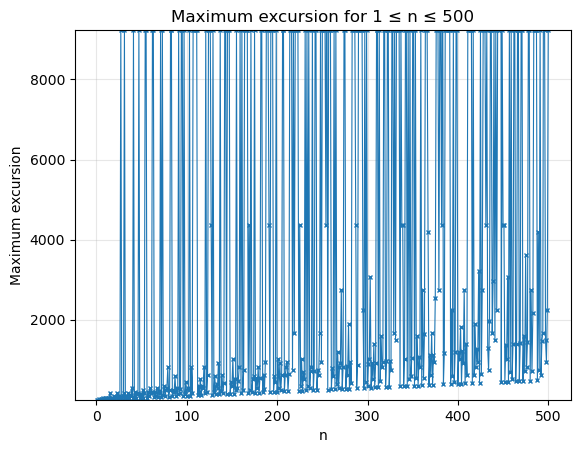

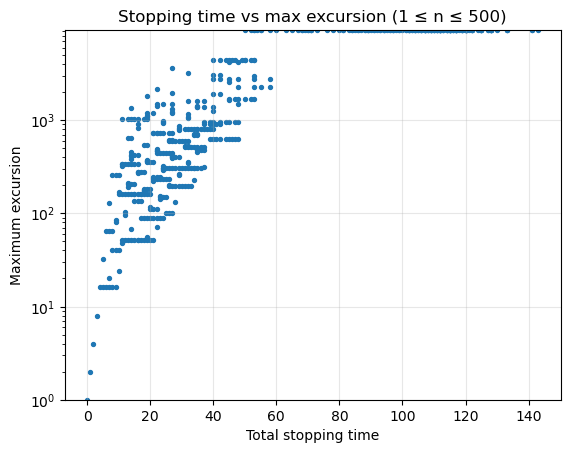

In [28]:
import sections.section1_standard_behaviour


N_values2 = [50, 200, 500]

for N in N_values2:

    print("\n-----------------------------")
    print("Running for N =", N)

    n_val, stop_t, n_exc = collatz_simulations(N)

    # Compute ranges first
    stop_min = min(stop_t)
    stop_max = max(stop_t)

    exc_min = min(n_exc)
    exc_max = max(n_exc)

    # Find where maxima occur
    n_stop = n_val[stop_t.index(stop_max)]
    n_exc_at_max = n_val[n_exc.index(exc_max)]

    print("Largest stopping time:", stop_max, "at n =", n_stop)
    print("Largest maximum excursion:", exc_max, "at n =", n_exc_at_max)

    print("Average stopping time:", round(sum(stop_t)/len(stop_t), 3))
    print("Range of stopping times:", stop_min, "to", stop_max)
    print("Range of maximum excursions:", exc_min, "to", exc_max)

    sections.section1_standard_behaviour.plot_stopping_time(n_val, stop_t, N)
    sections.section1_standard_behaviour.plot_max_excursion(n_val, n_exc, N)
    sections.section1_standard_behaviour.stopping_vs_excursion(stop_t, n_exc, N)

#### Stopping Time Plots:

For N = 50, we can already see noticeable variation between neighbouring starting values. There doesn’t initially appear to be any clear pattern, aside from a small increase in stopping times, although this may just be due to considering the first few integers.

When we compare this with the behaviour for N = 200 and N = 500, it reinforces how unpredictable the sequence is. The stopping times vary significantly even between nearby values of n, and there is no obvious trend. If anything, the irregularity seems to become more pronounced as the range increases.

#### Maximum Excursion Plots:

For N = 50, the maximum excursion plots are already showing us that many sequences increase well beyond their starting value before finally decreasing to 1. We can see that some values do remain relatively small, whereas others grow much larger, even in this small sample of numbers. We can also link this to branches of the Collatz Tree, as some numbers never get higher than their starting point, for example the main branch 1,2,4,8,16,32,64, which always decreases.

When comparing this to N = 200 and N = 500, we can see that this exact behaviour becomes more extreme. Maximum values are much higher, and the random variation is more noticeable. Similar to stopping times, there is no apparent pattern, as the growth also seems fairly irregular.

#### Stopping Times and Maximum Excursion: 

We can take from both of these plots that although all of these sequences eventually decrease and reach 1, they take very different paths to get there. Some have longer sequences, some reach higher values, and some exhibit both behaviours, while others show neither. This is consistent with the Collatz conjecture, as all tested values still converge despite the irregular behaviour.

Additionally, there does not appear to be a strong or consistent relationship between maximum excursion and stopping time. While some values that reach high maximum values also have long stopping times, this is not always the case, suggesting that these two aspects of the sequence behave somewhat independently.

## Section 4: The Collatz Tree

In this final section, I decided to do a bit of work on the Collatz Tree. After watching an interesting video by 'Veritasium' on the Collatz sequence, which included a range of visualisations produced by mathematicians, some of which were based on Collatz trees, I was inspired to define some simple functions to generate them. This then allowed me to produce outputs and explore their structure in a little more detail.

### What is a Collatz Tree?

The Collatz Tree focuses on defining the Collatz sequence in reverse. Instead of starting at an initial number and iterating the usual rule, we work backwards from 1 and consider what numbers would lead to it after each step. We can repeat this process for each level, creating branches of possible predecessors (or 'children') from each parent node.
  
For a given value \(n\), its possible predecessors are:

$$
\text{Parents}(n) =
\begin{cases}
2n, \\
\frac{n - 1}{3}, \quad \text{if } \frac{n - 1}{3} \in \mathbb{Z}, \text{ is odd, and positive}.
\end{cases}
$$

For any number n, there is always a possible predecessor of 2n. In some cases, this may be the only predecessor, or it may be accompanied by (n−1)/3, but only if this value is a positive odd integer. This means nodes have either one or two predecessors, which creates a tree-like, branching structure as we continue the process.

If we continue this indefinitely, it provides a way of visualising how all numbers eventually connect back to 1 - an alternative way to view the problem. However, in practice this becomes too complex to fully represent, so here the focus is on creating a simple process to generate part of the Collatz tree and display its levels.

Below are the first core functions, stated in ```collatz_tree.py``` which build the core steps of the Collatz Tree:

In [30]:
def node_parents(n):
    '''
    Creates parent nodes for one value n, similar to doing one_step()
    '''
    parents = []

    parents.append(2*n)

    if (n-1)%3 == 0:
        m = (n-1)//3
        if m%2 == 1 and m>0:
            parents.append(m)

    return parents

In [38]:
node_parents(4)

[8, 1]

In [35]:
node_parents(17)

[34]

In [40]:
def tree_generator(depth):
    '''
    Generates a set amount of layers of the Collatz Tree
    '''
    levels = []
    levels.append([1])      # level 0 starts with 1

    seen = [1]

    for i in range(depth):

        current_level = levels[i]
        next_level = []

        for n in current_level:
            for parent in node_parents(n):
                if parent not in seen:
                    next_level.append(parent)
                    seen.append(parent)

        levels.append(next_level)

    return levels

In [41]:
tree_generator(1)

[[1], [2]]

In [44]:
tree_generator(4)

[[1], [2], [4], [8], [16]]

As you can see ```node_parents()``` returns the predecessors for a set starting value 'n' and ```tree_generator()``` uses this initial function and iterates it from 1, to find all the predecessors in each level.

### Investigating tree structure

Obviously, it is very open ended from where you can go from here. I decided to investigate the structure of the trees and how can compare values as the depth increases.

#### Looking at the tree computations on their own

First to compute a set amount of levels and just look at this output individually.

In [48]:
depth = 8
levels = tree_generator(depth)

print("\nTree structure:")

for i in range(len(levels)):
    print("Level", i, ":", levels[i])
    print("Nodes in level:", len(levels[i]))
    print()


Tree structure:
Level 0 : [1]
Nodes in level: 1

Level 1 : [2]
Nodes in level: 1

Level 2 : [4]
Nodes in level: 1

Level 3 : [8]
Nodes in level: 1

Level 4 : [16]
Nodes in level: 1

Level 5 : [32, 5]
Nodes in level: 2

Level 6 : [64, 10]
Nodes in level: 2

Level 7 : [128, 21, 20, 3]
Nodes in level: 4

Level 8 : [256, 42, 40, 6]
Nodes in level: 4



As we can already see, printing the output in this way is a useful way of showing how each level is structured, rather than outputting all the nodes at once. It also highlights how the tree grows as we move further away from 1. We can begin to visualise how the branches are arranged, and it becomes clear that they are starting to split off as the levels increase.

#### Visualising the structure